# About this notebook

This notebook builds a hierarchical, team based agent system with **LangGraph** and **LangChain** that can research on the web, scrape pages, search patents, run code, and collaborate to write and persist a report to disk. It demonstrates how to compose multiple subgraphs under a top level supervisor while keeping tools, roles, and state explicit.

## What it shows

* **Two specialized teams** coordinated by supervisors

  1. **Research team** with search, scraping, Exa semantic search, and Google Patents
  2. **Document writing team** with outline creation, document read and write, editing, and a Python REPL for simple charts
* **Top level orchestrator** that routes work between the two teams and aggregates results
* **Tooling mix**: Tavily, SerpAPI, Exa, WebBaseLoader scraping, and a Python REPL
* **File persistence** in a working directory for outlines and the final report
* **Streaming runs** that print step by step updates and **Mermaid PNG** graph previews for each team and the supervisor graph

## What you will run

1. . Define research tools

   * `tavily_tool` for search results
   * `scrape_webpages` to pull and concatenate page contents
   * `patent_search` via SerpAPI Google Patents
   * `exa_search_tool` for neural search with highlight snippets
2. Define document tools

   * `create_outline`, `read_document`, `write_document`, `edit_document` that operate in a sandboxed working directory
   * `python_repl_tool` for quick calculations or charts printed to stdout
3. Build **worker nodes** using `create_react_agent` and **LLM supervisors** with structured routing that pick the next worker or finish.
4. Compile three graphs

   * `research_graph` for web research and patents
   * `paper_writing_graph` for outlining and writing with optional chart generation
   * `super_graph` that orchestrates both teams end to end
5. Execute an example

   * Ask about AI agents and patents with the research team
   * Write a poem to disk with the writing team
   * Run a full task that produces an 800 word semiconductor whitepaper, includes patent links and sources, and saves it to `semiconductor_whitepaper.txt`

## How it works

* **Supervisors**: Small LLM routers with structured output select the next worker from a fixed set or return FINISH.
* **Workers**: ReAct style agents bound to a specific tool set and prompt. Each worker returns a single concise message which is fed back to the supervisor.
* **State**: Uses `MessagesState` plus a simple `next` field. Messages flow across teams so the top level supervisor can coordinate.
* **Routing**: Implemented through `Command(goto=..., update=...)` to move between nodes while appending results to state.
* **Persistence**: File tools read and write under `WORKING_DIRECTORY`. The final task writes a complete report to disk.

## Why this pattern

* Clear separation of concerns makes behaviors predictable and testable.
* Supervisors keep control flow explicit and auditable.
* Tool use is bounded per worker which reduces prompt sprawl and improves reliability.
* The top level graph composes teams without coupling their internal details.

## Extend and adapt

* Add a citation validator between research and writing.
* Swap or add search providers.
* Replace Python REPL with a sandboxed executor.
* Persist checkpoints and traces with LangSmith for debugging and evaluation.

## Requirements and notes

* Required keys: `OPENAI_API_KEY`, `TAVILY_API_KEY`, `SERPAPI_API_KEY`, `EXA_API_KEY`.
* Web results and patent listings change over time. Outputs will vary run to run.
* File system tools write to the working directory. Use a sandbox for untrusted content or use it within a Docker setup.
* Streaming prints intermediate updates that help you trace decisions and tool calls.


In [ ]:
%%capture --no-stderr
%pip install -U langgraph langchain_community langchain_openai langchain-tavily langchain_experimental python-dotenv exa_py==1.16.1

In [ ]:
# Imports for API
from dotenv import load_dotenv
import os

load_dotenv()

NEBIUS_API_KEY = os.getenv('NEBIUS_API_KEY')
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
serp_api_key = os.getenv("SERPAPI_API_KEY")
SERPER_API_KEY = os.getenv("SERPER_API_KEY")
exa_api_key = os.getenv("EXA_API_KEY")

In [ ]:
!pip install tavily-python

<div class="admonition tip">
    <p class="admonition-title">Set up <a href="https://smith.langchain.com">LangSmith</a> for LangGraph development</p>
    <p style="padding-top: 5px;">
        Sign up for LangSmith to quickly spot issues and improve the performance of your LangGraph projects. LangSmith lets you use trace data to debug, test, and monitor your LLM apps built with LangGraph — read more about how to get started <a href="https://docs.smith.langchain.com">here</a>.
    </p>
</div>

## Create Tools

Each team will be composed of one or more agents each with one or more tools. Below, define all the tools to be used by your different teams.

We'll start with the research team.

**ResearchTeam tools**

The research team can use a search engine and url scraper to find information on the web. Feel free to add additional functionality below to boost the team performance!

In [ ]:
from typing import Annotated, List

from langchain_community.document_loaders import WebBaseLoader
from langchain_tavily import TavilySearch
from langchain_core.tools import tool




In [ ]:
import os
import datetime
from typing import Dict, Any

from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch, TavilyExtract

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import StreamWriter
from langgraph.prebuilt import ToolNode

from langchain_core.messages import HumanMessage, AIMessage


**Document writing team tools**

Next up, we will give some tools for the doc writing team to use.
We define some bare-bones file-access tools below.

Note that this gives the agents access to your file-system, which can be unsafe. We also haven't optimized the tool descriptions for performance.

In [ ]:
from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Optional

from typing_extensions import TypedDict
from langchain_community.tools.tavily_search import TavilySearchResults
from typing import Annotated, List

from langchain_community.document_loaders import WebBaseLoader
from langchain_tavily import TavilySearch
from langchain_core.tools import tool


# Define a persistent working directory
WORKING_DIRECTORY = Path("/content/working_directory")

# Ensure the working directory exists
if not WORKING_DIRECTORY.exists():
    WORKING_DIRECTORY.mkdir(parents=True)
    print(f"Created working directory: {WORKING_DIRECTORY}")
else:
    print(f"Working directory already exists: {WORKING_DIRECTORY}")

from langchain_community.utilities import SerpAPIWrapper
from exa_py import Exa
import json
from typing import List

import re
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from langchain_core.tools import tool
from typing import List

# --- Load the Encoder Model (The Analyst's "Brain") ---
# This is done once at the start.
try:
    print("Loading Analyst (ModernBERT) model...")
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Using the exact model you provided
    tok = AutoTokenizer.from_pretrained("answerdotai/ModernBERT-base", use_fast=True)
    enc = AutoModel.from_pretrained("answerdotai/ModernBERT-base", trust_remote_code=True).eval().to(device)

    print(f"Analyst (ModernBERT) loaded successfully on {device}.")
except Exception as e:
    print(f"Warning: Could not load ModernBERT. Analyst will not work. Error: {e}")
    # Define dummy objects so the rest of the code doesn't crash
    tok, enc, device = None, None, "cpu"


def _sent_split(text):
    """A simple, fast sentence splitter"""
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if len(s.strip()) > 0]

@tool("semantic_filter_tool")
def semantic_filter_tool(query: str, documents: List[str], k: int = 10) -> str:
    """
    The Analyst's tool. Uses ModernBERT (an encoder model) to perform
    extractive summarization. It finds the top 'k' most relevant sentences
    from a list of documents that match a specific query.
    """
    if not enc:
        return "Error: ModernBERT model is not loaded."

    print(f"--- 🕵️ Analyst (ModernBERT) processing {len(documents)} docs... ---")

    # 1. Create a bank of sentences with provenance
    bank, provenance = [], []
    for i, doc_text in enumerate(documents):
        for s in _sent_split(doc_text):
            bank.append(s)
            provenance.append(f"Source Doc [{i}]") # Keep track of where it came from

    if not bank:
        return "No text found in documents."

    # 2. Encode query + all sentences in the bank
    batch = [query] + bank
    inputs = tok(batch, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.no_grad():
        H = enc(**inputs).last_hidden_state
        attn = inputs["attention_mask"].unsqueeze(-1)
        # Mean-pool to get sentence embeddings
        emb = (H * attn).sum(dim=1) / attn.sum(dim=1)

    q = emb[0]  # Query embedding
    S = emb[1:] # Sentence embeddings

    # 3. Score sentences based on query similarity
    score = F.cosine_similarity(S, q.unsqueeze(0)).flatten()

    # 4. Pick the top k
    top_k_indices = torch.topk(score, k=min(k, len(bank))).indices

    # 5. Format the output
    results = []
    for idx in top_k_indices:
        i = idx.item()
        results.append({
            "text": bank[i],
            "source": provenance[i],
            "score": round(score[i].item(), 4)
        })

    return json.dumps(results, indent=2)


tavily_search = TavilySearch(
    max_results=10,
    topic="general",
    search_depth="basic",
)

tavily_extract = TavilyExtract(
    extract_depth="advanced",
    include_images=False,
)

@tool
def scrape_webpages(urls: List[str]) -> str:
    """Use requests and bs4 to scrape the provided web pages for detailed information."""
    loader = WebBaseLoader(urls)
    docs = loader.load()
    return "\n\n".join(
        [
            f'<Document name="{doc.metadata.get("title", "")}">\n{doc.page_content}\n</Document>'
            for doc in docs
        ]
    )

from langchain_community.utilities import GoogleSerperAPIWrapper

_serper = GoogleSerperAPIWrapper(type="search", hl="en", gl="us", tbs="qdr:y")

@tool("patent_search")
def patent_search(topic: str, max_items: int = 10) -> str:
    """
    Past-year Google Patents hits via Serper. Returns JSON with title, link, date, snippet.
    """
    q = f'site:patents.google.com ("{topic}")'
    res = _serper.results(q)
    organics = res.get("organic", [])
    hits = [
        {
            "title": o.get("title",""),
            "link": o.get("link",""),
            "date": o.get("date") or o.get("publishedDate") or o.get("publishedTime"),
            "snippet": o.get("snippet",""),
        }
        for o in organics if "patents.google.com" in o.get("link","")
    ][:max_items]
    if not hits:
        return "No recent Google Patents results found."
    return json.dumps(hits, indent=2)



@tool("exa_search_tool")
def exa_search_tool(question: str) -> str:
    """Tool using Exa's Python SDK to run semantic search and return result highlights."""
    exa = Exa(exa_api_key)

    response = exa.search_and_contents(
        question,
        type="neural",
        use_autoprompt=True,
        num_results=5,
        highlights=True
    )

    results = []
    for idx, eachResult in enumerate(response.results):
        result = {
            "Title": eachResult.title,
            "URL": eachResult.url,
            "Highlight": "".join(eachResult.highlights)
        }
        results.append(result)

    return json.dumps(results)


@tool
def create_outline(
    points: Annotated[List[str], "List of main points or sections."],
    file_name: Annotated[str, "File path to save the outline."],
) -> Annotated[str, "Path of the saved outline file."]:
    """Create and save an outline."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        for i, point in enumerate(points):
            file.write(f"{i + 1}. {point}\n")
    return f"Outline saved to {file_name}"


@tool
def read_document(
    file_name: Annotated[str, "File path to read the document from."],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()
    if start is None:
        start = 0
    return "\n".join(lines[start:end])


@tool
def write_document(
    content: Annotated[str, "Text content to be written into the document."],
    file_name: Annotated[str, "File path to save the document."],
) -> Annotated[str, "Path of the saved document file."]:
    """Create and save a text document."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.write(content)
    return f"Document saved to {file_name}"


@tool
def edit_document(
    file_name: Annotated[str, "Path of the document to be edited."],
    inserts: Annotated[
        Dict[int, str],
        "Dictionary where key is the line number (1-indexed) and value is the text to be inserted at that line.",
    ],
) -> Annotated[str, "Path of the edited document file."]:
    """Edit a document by inserting text at specific line numbers."""

    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()

    sorted_inserts = sorted(inserts.items())

    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number - 1, text + "\n")
        else:
            return f"Error: Line number {line_number} is out of range."

    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"



Working directory already exists: /content/working_directory
Loading Analyst (ModernBERT) model...
Analyst (ModernBERT) loaded successfully on cuda.


## Helper Utilities

We are going to create a few utility functions to make it more concise when we want to:

1. Create a worker agent.
2. Create a supervisor for the sub-graph.

These will simplify the graph compositional code at the end for us so it's easier to see what's going on.

In [ ]:
from typing import List, Optional, Literal
from langchain_core.language_models.chat_models import BaseChatModel
import operator
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.types import Command
from langchain_core.messages import HumanMessage, trim_messages
from langchain_core.messages import BaseMessage

class State(MessagesState):
    # This tracks the team's conversation internally
    messages: Annotated[List[BaseMessage], operator.add]
    # This provides each worker with context on the others' skill sets
    members: str
    # This is how the supervisor tells langgraph who has to work next
    next: str
    # This tracks the shared directory state
    current_files: str

def make_supervisor_node(llm: BaseChatModel, members: list[str]) -> str:
    options = ["FINISH"] + members
    system_prompt = (
    "You are the Thinker, a supervisor.\n"
    "you have the following team members: {members}"
    "Default order: search -> exa_search -> patent_research -> analyst -> note_taker -> doc_writer -> FINISH.\n"
    "Only send the analyst after at least one research worker returned content.\n"
    "When finished, write key findings to file via doc_writer. Cite sources."
)


    class Router(TypedDict):
        """Worker to route to next. If no workers needed, route to FINISH."""

        next: Literal[*options]

    def supervisor_node(state: State) -> Command[Literal[*members, "__end__"]]:
        """An LLM-based router."""
        messages = [
            {"role": "system", "content": system_prompt},
        ] + state["messages"]
        response = llm.with_structured_output(Router).invoke(messages)
        goto = response["next"]
        if goto == "FINISH":
            goto = END

        return Command(goto=goto, update={"next": goto})

    return supervisor_node

In [ ]:
from __future__ import annotations
from typing import Any, Dict, Literal, Sequence
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
from langgraph.types import Command

def make_react_worker_node(
    *,
    llm: ChatOpenAI,
    name: str,
    tools: list,
    prompt: str | None = None,
    goto: str = "supervisor",
):
    agent = create_react_agent(llm, tools=tools, prompt=prompt)

    def node(state: State) -> Command[Literal["supervisor"]]:
        result: Dict[str, Any] = agent.invoke(state)
        msgs: Sequence[BaseMessage] = result.get("messages", [])
        content = getattr(msgs[-1], "content", "") if msgs else ""
        return Command(
            update={"messages": [HumanMessage(content=content, name=name)]},
            goto=goto,
        )

    return node


## Define Agent Teams

Now we can get to define our hierarchical teams. "Choose your player!"

### Research Team

The research team will have a search agent and a web scraping "research_agent" as the two worker nodes. Let's create those, as well as the team supervisor.

Now that we've created the necessary components, defining their interactions is easy. Add the nodes to the team graph, and define the edges, which determine the transition criteria.

In [ ]:
fast_llm = ChatOpenAI(
    model="Qwen/Qwen3-32B-fast",
    temperature=0,
    api_key=NEBIUS_API_KEY,
    base_url="https://api.studio.nebius.ai/v1/",
    extra_body={
        "top_k": 20,
        "chat_template_kwargs": {"enable_thinking": False},
    },
)


thinker_llm = ChatOpenAI(
    model="Qwen/Qwen3-235B-A22B-Thinking-2507",
    temperature=0,
    api_key=NEBIUS_API_KEY,
    base_url="https://api.studio.nebius.ai/v1/",
    # Keep thoughts internal and bounded
    extra_body={
        "chat_template_kwargs": {"enable_thinking": True},
        # Set budget
        "thinking": {"type": "token", "budget": 1536}
    },
)

supervisor_llm = ChatOpenAI(
    model="gpt-4.1",
    temperature=0
)

In [ ]:
# Prompts help to keep roles sharp
#SEARCH_PROMPT = """Role: Web researcher. Use the search tool and return a
#concise research note with sources. No follow-up questions."""

today = datetime.datetime.now().strftime("%Y-%m-%d")
SEARCH_PROMPT = f"""
You are a precise research agent. The date is {today}.
When the user asks for sources from a specific site or domain, pass that intent to the Tavily search tool using include_domains.
Typical flow:
1 search with TavilySearch to find relevant pages
2 extract with TavilyExtract on the top results
3 write a clear synthesis with short bullet points and inline bracketed citations pointing to the URLs you actually used
Be concise and evidence based.
""".strip()

EXA_PROMPT = """Role: Research assistant. You can search for all recent info
on Exa Search. Your response should clearly articulate the key points you found."""

PATENT_PROMPT = """Role: Market researcher with 20 years of experience.
You are very knowledgeable in patent research and in finding up-to-date info
about patents using the Google Patents API."""

NOTE_PROMPT = """You can read documents and create outlines for the document
writer. Don't ask follow-up questions."""

WRITER_PROMPT = """You can read, write and edit documents based on note-taker's
outlines. Don't ask follow-up questions."""

ANALYST_PROMPT = """
You are the Analyst. You must call the `semantic_filter_tool` exactly once.
Inputs:
- query: the current task topic or question
- documents: a list of raw strings gathered by teammates

Rules:
- Do not answer the user
- Do not do free form writing
- Only return the tool result to the supervisor
""".strip()


specs = [
    dict(name="search",          tools=[tavily_search, tavily_extract], prompt=SEARCH_PROMPT,      llm=fast_llm),
    dict(name="exa_search",      tools=[exa_search_tool],               prompt=EXA_PROMPT,         llm=fast_llm),
    dict(name="patent_research", tools=[patent_search],                 prompt=PATENT_PROMPT,      llm=fast_llm),
    dict(name="analyst",         tools=[semantic_filter_tool],          prompt=ANALYST_PROMPT,     llm=thinker_llm),
    dict(name="note_taker",      tools=[create_outline, read_document], prompt=NOTE_PROMPT,        llm=fast_llm),
    dict(name="doc_writer",      tools=[write_document, edit_document, read_document], prompt=WRITER_PROMPT, llm=fast_llm),
]

nodes = {
    s["name"]: make_react_worker_node(llm=s["llm"], name=s["name"], tools=s["tools"], prompt=s["prompt"])
    for s in specs
}


search_node = nodes["search"]
exa_search_node = nodes["exa_search"]
patent_research_node = nodes["patent_research"]
analyst_node = nodes["analyst"]
note_taking_node = nodes["note_taker"]
doc_writing_node = nodes["doc_writer"]

# Supervisor that can coordinate all four
research_supervisor_node = make_supervisor_node(
    supervisor_llm, ["exa_search", "patent_research", "analyst", "note_taker", "doc_writer"]
)


/tmp/ipython-input-3604616990.py:16: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm, tools=tools, prompt=prompt)


In [ ]:
research_builder = StateGraph(State)

# register nodes
research_builder.add_node("supervisor", research_supervisor_node)
research_builder.add_node("exa_search", exa_search_node)
research_builder.add_node("patent_research", patent_research_node)
research_builder.add_node("analyst", analyst_node)
research_builder.add_node("note_taker", note_taking_node)
research_builder.add_node("doc_writer", doc_writing_node)

# --- Define edges ---
research_builder.add_edge(START, "supervisor")
research_builder.add_edge("exa_search", "supervisor")
research_builder.add_edge("patent_research", "supervisor")
research_builder.add_edge("analyst", "supervisor")
research_builder.add_edge("note_taker", "supervisor")
research_builder.add_edge("doc_writer", "supervisor")


research_graph = research_builder.compile()

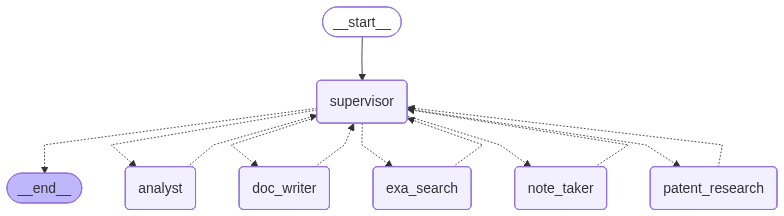

In [ ]:
from IPython.display import Image, display

display(Image(research_graph.get_graph().draw_mermaid_png()))

We can give this team work directly. Try it out below.

In [ ]:
for s in research_graph.stream(
    {"messages": [("user", """ Research the latest developments in AI agents,
    specifically coding agents. Write at least 500 words about the findings.
    Include patents! And include all links to references!
    """)]},
    {"recursion_limit": 100},
):
    print(s)
    print("---")


{'supervisor': {'next': 'exa_search'}}
---
{'exa_search': {'messages': [HumanMessage(content='### Latest Developments in AI Agents: A Focus on Coding Agents\n\nAI agents, particularly those focused on coding, are rapidly evolving and transforming the landscape of software development. These agents, powered by large language models (LLMs), are capable of autonomously planning, executing, and interacting with various tools such as compilers, debuggers, and version control systems. This paradigm shift is not just about generating code but involves decomposing complex tasks into manageable steps, coordinating multi-step processes, and adapting based on feedback. The implications of these advancements are profound, as they promise to reshape traditional software development practices.\n\n#### AI Agentic Programming\n\nA recent survey titled "AI Agentic Programming: A Survey of Techniques, Challenges, and Opportunities" provides a comprehensive overview of the field. The authors, from the Un

/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:282: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
W1102 12:49:47.802000 1518 torch/_inductor/utils.py:1436] [1/0_1] Not enough SMs to use max_autotune_gemm mode


{'analyst': {'messages': [HumanMessage(content='\n\n[\n  {\n    "text": "### Patents on AI Agents\\n\\nWhile the provided search results do not explicitly mention patents on AI agents, it is worth noting that the field of AI is rapidly evolving, and numerous patents are likely being filed to protect innovations in this area.",\n    "source": "Source Doc [1]",\n    "score": 0.9658\n  },\n  {\n    "text": "### Patents on AI Agents\\n\\nWhile the provided search results do not explicitly mention patents on AI agents, it is worth noting that the field of AI is rapidly evolving, and numerous patents are likely being filed to protect innovations in this area.",\n    "source": "Source Doc [0]",\n    "score": 0.9658\n  },\n  {\n    "text": "### Latest Developments in AI Agents: A Focus on Coding Agents\\n\\nAI agents, particularly those focused on coding, are rapidly evolving and transforming the landscape of software development.",\n    "source": "Source Doc [0]",\n    "score": 0.956\n  },\n 

# Latest Developments in AI Agents: A Focus on Coding Agents

AI agents, particularly those focused on coding, are rapidly evolving and transforming the landscape of software development. These agents, powered by large language models (LLMs), are capable of autonomously planning, executing, and interacting with various tools such as compilers, debuggers, and version control systems. This paradigm shift is not just about generating code but involves decomposing complex tasks into manageable steps, coordinating multi-step processes, and adapting based on feedback. The implications of these advancements are profound, as they promise to reshape traditional software development practices.

#### AI Agentic Programming

A recent survey titled "AI Agentic Programming: A Survey of Techniques, Challenges, and Opportunities" provides a comprehensive overview of the field. The authors, from the University of Leeds, introduce a taxonomy of agent behaviors and system architectures, examining relevant techniques for planning, context management, tool integration, and execution monitoring. This survey highlights the importance of context-awareness and adaptability in AI agents, which are crucial for handling the dynamic nature of software development tasks. The paper also discusses the challenges associated with these agents, including the need for robust planning mechanisms and the integration of diverse tools.

#### SWE-agent: Agent-Computer Interfaces

Another significant development is the introduction of SWE-agent, a system that facilitates the use of language model agents in software engineering tasks. As described in the paper "SWE-agent: Agent-Computer Interfaces Enable Automated Software Engineering," this system is designed to enable LM agents to autonomously use computers to solve software engineering problems. The authors argue that just as humans benefit from powerful software applications, LM agents can also benefit from specially-built interfaces tailored to their needs. This approach not only enhances the performance of these agents but also opens up new possibilities for automated software engineering.

#### AgentCoder: Multi-Agent-based Code Generation

The paper "AgentCoder: Multi-Agent-based Code Generation with Iterative Testing and Optimisation" presents a novel approach to code generation using multi-agent systems. This method involves iterative testing and optimization, allowing for the refinement of generated code through continuous feedback. The authors demonstrate how this approach can lead to more robust and efficient code generation, highlighting the potential of multi-agent systems in the realm of AI-driven software development.

#### OpenHands: An Open Platform for AI Software Developers

The "OpenHands" project, as detailed in the paper "OpenHands: An Open Platform for AI Software Developers as Generalist Agents," introduces an open platform designed to support AI software developers as generalist agents. This platform aims to provide a comprehensive environment for AI agents to perform a wide range of software development tasks. The authors emphasize the importance of an open and collaborative approach in fostering innovation and advancing the capabilities of AI agents in software development.

### Patents on AI Agents

While the provided search results do not explicitly mention patents on AI agents, it is worth noting that the field of AI is rapidly evolving, and numerous patents are likely being filed to protect innovations in this area. Companies and research institutions are increasingly recognizing the potential of AI agents and are investing in developing proprietary technologies. These patents may cover various aspects of AI agent development, including novel algorithms, system architectures, and user interfaces.

### Conclusion

The advancements in AI agents, particularly in the realm of coding, are reshaping the software development landscape. These agents are not only capable of generating code but also of autonomously planning, executing, and adapting to complex tasks. The introduction of systems like SWE-agent and platforms like OpenHands is paving the way for more efficient and effective software development practices. As the field continues to evolve, it is essential to stay informed about the latest developments and innovations in AI agents to fully leverage their potential.

For further reading and detailed information, you can refer to the following resources:
- [AI Agentic Programming: A Survey of Techniques, Challenges, and Opportunities](https://arxiv.org/html/2508.11126v2/)
- [SWE-agent: Agent-Computer Interfaces Enable Automated Software Engineering](https://ui.adsabs.harvard.edu/abs/2024arXiv240515793Y/abstract)
- [AgentCoder: Multi-Agent-based Code Generation with Iterative Testing and Optimisation](https://www.alphaxiv.org/abs/2312.13010v3)
- [OpenHands: An Open Platform for AI Software Developers as Generalist Agents](https://arxiv.org/abs/2407.16741)